# Paper-style β-VAE adapted to atmospheric C1s spectra

This notebook implements the fully connected β-VAE described in *Unsupervised real-world knowledge extraction via disentangled variational autoencoders for photon diagnostics*, adapted to the self-contained atmospheric C1s HDF5 dataset.

The paper used `14000 → 2824 → 579 → 117 → 24 → 12`, where the 24 encoder outputs represent 12 means and 12 log-variances. The atmospheric C1s spectra contain 401 points, so the corresponding network used here is `401 → 256 → 128 → 64 → 24 → 12`, with the mirrored decoder `12 → 64 → 128 → 256 → 401`. The VAE architecture itself is unchanged from the previous notebook: twelve latent variables, fully connected layers, Mish activations, a sigmoid output, and the β-weighted KL objective.

Peak and sample parameters are **not used for training**. They are retained only to test whether physical properties emerge in the latent space. `expected_total_counts` is used as the reconstruction target while `noisy_counts` remains the input, preventing the network from being rewarded for reproducing acquisition noise.

## Requirements

Use a Python environment containing PyTorch, NumPy, h5py, and Matplotlib. If necessary, install them in the active notebook kernel with:

```python
%pip install torch numpy h5py matplotlib
```

The cell is shown as documentation rather than executed automatically so the notebook does not modify your environment without permission.

In [1]:
from pathlib import Path
import copy
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
from atmospheric_dataset import h5_manifest, load_atmospheric_c1s
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}; device={DEVICE}")

PyTorch 2.6.0; device=cpu


In [2]:
# Override this path when running the notebook from another working directory.
DATA_ROOT_OVERRIDE = None
DATA_ROOT = Path(DATA_ROOT_OVERRIDE) if DATA_ROOT_OVERRIDE else Path.cwd() / "atmospheric_c1s_h5"
if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Atmospheric HDF5 dataset not found: {DATA_ROOT}")

CACHE_DIR = Path.cwd() / "data_cache"
OUTPUT_DIR = Path.cwd() / "outputs" / "atmospheric_beta_vae"
CACHE_FILE = CACHE_DIR / "atmospheric_c1s_401.npz"
CHECKPOINT_FILE = OUTPUT_DIR / "best_beta_vae.pt"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_LENGTH = 401
REBUILD_CACHE = False  # Set True only to force rebuilding an otherwise current cache.
case_files = sorted(DATA_ROOT.glob("atmospheric_c1s_case_*.h5"))
print(f"Atmospheric C1s data: {DATA_ROOT}")
print(f"Discovered physical cases: {len(case_files):,}")
print(f"Cache: {CACHE_FILE}")

Atmospheric C1s data: /home/umar/Downloads/spectraVAE/atmospheric_c1s_h5
Discovered physical cases: 12,000
Cache: /home/umar/Downloads/spectraVAE/data_cache/atmospheric_c1s_401.npz


## Load the atmospheric HDF5 spectra

Each HDF5 acquisition becomes one sample. The loader validates the dataset schema, 401-point binding-energy grid, finite spectra, component order, and train/validation/test labels. It loads the noisy input, noise-free target, transport background, five peak components, atmospheric sample labels, and acquisition labels.

All five acquisitions from a physical case retain the split embedded in that case file, preventing noise realizations from leaking between partitions. A manifest of HDF5 paths, sizes, and modification times is stored with the cache, so adding or changing case files automatically rebuilds the extracted dataset on the next fresh notebook run.

In [3]:
# HDF5 loading is implemented in atmospheric_dataset.py and invoked below.


In [4]:
current_manifest = h5_manifest(DATA_ROOT)
cache_is_current = False
if CACHE_FILE.exists() and not REBUILD_CACHE:
    with np.load(CACHE_FILE, allow_pickle=False) as cached:
        cache_is_current = ("h5_manifest" in cached.files and
                            np.array_equal(cached["h5_manifest"], current_manifest))

if not cache_is_current:
    dataset = load_atmospheric_c1s(DATA_ROOT, TARGET_LENGTH)
    np.savez_compressed(CACHE_FILE, **dataset, h5_manifest=current_manifest)
    print(f"Saved {CACHE_FILE}")
else:
    with np.load(CACHE_FILE, allow_pickle=False) as cached:
        dataset = {name: cached[name] for name in cached.files if name != "h5_manifest"}
    print(f"Loaded {CACHE_FILE}")

print(f"Spectra: {dataset['noisy'].shape}")
print(f"Independent cases: {np.unique(dataset['case_id']).size}")
print(f"Independent physical spectra: {np.unique(dataset['source']).size}")
print(f"Components: {', '.join(dataset['component_names'].tolist())}")
print("Split cases:", {name: np.unique(dataset['case_id'][dataset['split'] == name]).size
                       for name in ('train', 'validation', 'test')})
print(f"Count range: {dataset['noisy'].min():.1f}–{dataset['noisy'].max():.1f}")

# Preflight: repeated noisy sweeps do not add new physical conditions.
_, representative_idx = np.unique(dataset["source"], return_index=True)
preflight_features = {
    "photon energy": dataset["photon_energy"][representative_idx],
    **{f"{name} center": dataset["peak_center"][representative_idx, i]
       for i, name in enumerate(dataset["component_names"])},
    **{f"{name} width": dataset["peak_width"][representative_idx, i]
       for i, name in enumerate(dataset["component_names"])},
    **{f"{name} fraction": dataset["peak_fraction"][representative_idx, i]
       for i, name in enumerate(dataset["component_names"])},
    "aging index": dataset["aging_index"][representative_idx],
    "oxygen-to-carbon ratio": dataset["oxygen_to_carbon_ratio"][representative_idx],
    "mass density": dataset["mass_density_g_cm3"][representative_idx],
    "band gap": dataset["band_gap_eV"][representative_idx],
    "charge shift": dataset["charge_shift_eV"][representative_idx],
    "log total area": np.log1p(dataset["expected_total"][representative_idx].sum(axis=1)),
    "log background area": np.log1p(dataset["background"][representative_idx].sum(axis=1)),
}
constant_features = []
print("\nPhysical-condition variation (rounded unique values):")
for name, values in preflight_features.items():
    unique_count = np.unique(np.round(values, 6)).size
    print(f"  {name:<24} {unique_count:5d}")
    if unique_count < 2:
        constant_features.append(name)
if constant_features:
    print("WARNING: constant variables cannot be learned independently:", constant_features)

varying_names = [name for name, values in preflight_features.items() if np.ptp(values) > 1e-6]
varying_values = np.column_stack([preflight_features[name] for name in varying_names])
feature_correlation = np.corrcoef(varying_values, rowvar=False)
strong_pairs = []
for i in range(len(varying_names)):
    for j in range(i + 1, len(varying_names)):
        if abs(feature_correlation[i, j]) >= 0.98:
            strong_pairs.append((varying_names[i], varying_names[j], feature_correlation[i, j]))
if strong_pairs:
    print("WARNING: strongly coupled physical variables (|r| >= 0.98):")
    for left, right, value in strong_pairs:
        print(f"  {left} / {right}: r={value:+.3f}")

_, sweeps_per_source = np.unique(dataset["source"], return_counts=True)
print(f"Noisy sweeps per physical spectrum: min={sweeps_per_source.min()}, "
      f"median={np.median(sweeps_per_source):.0f}, max={sweeps_per_source.max()}")

Saved /home/umar/Downloads/spectraVAE/data_cache/atmospheric_c1s_401.npz
Spectra: (60000, 401)
Independent cases: 12000
Independent physical spectra: 12000
Components: CC_CH, C_O, C_eq_O, O_C_eq_O, pi_pi_star
Split cases: {'train': 8353, 'validation': 1839, 'test': 1808}
Count range: 0.0–150642.0

Physical-condition variation (rounded unique values):
  photon energy                1
  CC_CH center             11439
  C_O center               11496
  C_eq_O center            11459
  O_C_eq_O center          11435
  pi_pi_star center        11435
  CC_CH width              11901
  C_O width                11896
  C_eq_O width             11905
  O_C_eq_O width           11917
  pi_pi_star width         11887
  CC_CH fraction           11924
  C_O fraction             10521
  C_eq_O fraction          10460
  O_C_eq_O fraction        10389
  pi_pi_star fraction       3211
  aging index              11913
  oxygen-to-carbon ratio   10442
  mass density             11892
  band gap          

## Leakage-safe split and normalization

The train/validation/test assignment packaged in each physical-case HDF5 file is used directly. All repeated acquisitions from one simulated condition therefore remain in the same partition. The notebook asserts that the resulting case sets are disjoint before training.

The dataset stores Poisson-like non-negative counts with a much wider dynamic range than the paper's 8-bit ADC values. The notebook therefore uses the variance-stabilizing Anscombe transform `2√(x + 3/8)`, scaled from training data into `[0, 1]`. Training batches use inverse-frequency sampling by physical case (`source`), so repeated acquisitions improve denoising without making one simulated condition dominate.

In [5]:
case_ids = dataset["case_id"]
all_cases = np.unique(case_ids)

# Use the split packaged with each physical case.
representative_order = np.argsort(case_ids[representative_idx])
case_representative = representative_idx[representative_order]
assert np.array_equal(case_ids[case_representative], all_cases)
case_split = dataset["split"][case_representative]
train_cases = set(all_cases[case_split == "train"])
val_cases = set(all_cases[case_split == "validation"])
test_cases = set(all_cases[case_split == "test"])
train_idx = np.flatnonzero(dataset["split"] == "train")
val_idx = np.flatnonzero(dataset["split"] == "validation")
test_idx = np.flatnonzero(dataset["split"] == "test")
assert train_cases.isdisjoint(val_cases | test_cases)
assert val_cases.isdisjoint(test_cases)
assert len(train_idx) + len(val_idx) + len(test_idx) == len(case_ids)

def anscombe(x):
    return 2.0 * np.sqrt(np.maximum(x, 0.0) + 3.0 / 8.0)

# Five percent headroom prevents saturation at the largest training count.
TRANSFORM_SCALE = 1.05 * float(anscombe(dataset["expected_total"][train_idx]).max())
if not np.isfinite(TRANSFORM_SCALE) or TRANSFORM_SCALE <= 0:
    raise ValueError("Invalid Anscombe normalization scale.")

def normalize_counts(x):
    return np.clip(anscombe(x) / TRANSFORM_SCALE, 0.0, 1.0).astype(np.float32)

def denormalize_counts(x):
    transformed = np.clip(x, 0.0, 1.0) * TRANSFORM_SCALE
    return np.maximum((transformed / 2.0) ** 2 - 3.0 / 8.0, 0.0)

x_all = normalize_counts(dataset["noisy"])
target_all = normalize_counts(dataset["expected_total"])

BATCH_SIZE = 512 if torch.cuda.is_available() else 256
TRAIN_DRAWS_PER_SOURCE = 12

def make_loader(indices, training=False):
    tensors = TensorDataset(torch.from_numpy(x_all[indices]), torch.from_numpy(target_all[indices]))
    sampler = None
    if training:
        sources = dataset["source"][indices]
        unique_sources, source_counts = np.unique(sources, return_counts=True)
        count_by_source = dict(zip(unique_sources.tolist(), source_counts.tolist()))
        weights = torch.as_tensor([1.0 / count_by_source[s] for s in sources], dtype=torch.double)
        epoch_samples = min(len(indices), TRAIN_DRAWS_PER_SOURCE * len(unique_sources))
        sampler_generator = torch.Generator().manual_seed(SEED)
        sampler = WeightedRandomSampler(
            weights, num_samples=epoch_samples, replacement=True, generator=sampler_generator
        )
    return DataLoader(
        tensors, batch_size=BATCH_SIZE, shuffle=False, sampler=sampler, num_workers=0,
        pin_memory=torch.cuda.is_available(), drop_last=False,
    )

train_loader = make_loader(train_idx, training=True)
val_loader = make_loader(val_idx)
test_loader = make_loader(test_idx)
print(f"train={len(train_idx):,}, validation={len(val_idx):,}, test={len(test_idx):,}")
print(f"train cases={len(train_cases)}, validation cases={len(val_cases)}, test cases={len(test_cases)}")
print(f"train physical spectra={np.unique(dataset['source'][train_idx]).size:,}; "
      f"balanced draws/epoch={len(train_loader.sampler):,}; batch size={BATCH_SIZE}")
print("Using train/validation/test assignments embedded in the HDF5 files.")
print(f"Anscombe normalization scale={TRANSFORM_SCALE:.4f}")

train=41,765, validation=9,195, test=9,040
train cases=8353, validation cases=1839, test cases=1808
train physical spectra=8,353; balanced draws/epoch=41,765; batch size=256
Using train/validation/test assignments embedded in the HDF5 files.
Anscombe normalization scale=813.2975


## β-VAE architecture

The final encoder layer produces 24 values, split into twelve-dimensional `mu` and `logvar`. The decoder mirrors the encoder but excludes that distribution-parameter layer, as in the paper.

In [6]:
class BetaVAE(nn.Module):
    def __init__(self, input_dim=401, latent_dim=12):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.Mish(),
            nn.Linear(256, 128), nn.Mish(),
            nn.Linear(128, 64), nn.Mish(),
        )
        self.latent_statistics = nn.Linear(64, 2 * latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.Mish(),
            nn.Linear(64, 128), nn.Mish(),
            nn.Linear(128, 256), nn.Mish(),
            nn.Linear(256, input_dim), nn.Sigmoid(),
        )
        self.apply(self._initialize)

    @staticmethod
    def _initialize(module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)

    def encode(self, x):
        statistics = self.latent_statistics(self.encoder(x))
        return statistics.chunk(2, dim=-1)

    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = BetaVAE(input_dim=TARGET_LENGTH, latent_dim=12).to(DEVICE)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

BetaVAE(
  (encoder): Sequential(
    (0): Linear(in_features=401, out_features=256, bias=True)
    (1): Mish()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): Mish()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): Mish()
  )
  (latent_statistics): Linear(in_features=64, out_features=24, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): Mish()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): Mish()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): Mish()
    (6): Linear(in_features=256, out_features=401, bias=True)
    (7): Sigmoid()
  )
)
Trainable parameters: 290,857


## Training

The VAE architecture remains the paper-style network above. The reconstruction objective is adapted to the atmospheric dataset's noise model: noisy counts are encoded, while the decoder is compared with the noise-free expected spectrum. Pointwise and derivative errors are divided by each target spectrum's transformed energy, so weak spectra are not overwhelmed by high-count spectra. These relative shape terms are supplemented with a robust log-integrated-area loss. The previous maximum-bin peak-height loss remains omitted because it rewards isolated spikes rather than physically broad peaks. β is warmed from zero to the paper's `0.034`, allowing reconstruction to form before enforcing the normal prior. Validation uses the deterministic latent mean, and CUDA training uses automatic mixed precision while all losses remain in float32.

In [7]:
BETA_MAX = 0.034
KL_WARMUP_EPOCHS = 50
EPOCHS = 400
LEARNING_RATE = 3e-4
MIN_LEARNING_RATE = 1e-6
EARLY_STOPPING_PATIENCE = 50
MIN_DELTA = 1e-4
GRADIENT_CLIP_NORM = 5.0
FIRST_DIFFERENCE_WEIGHT = 0.5
SECOND_DIFFERENCE_WEIGHT = 0.1
AREA_WEIGHT = 2.0
SHAPE_ENERGY_FLOOR = 1e-4
USE_AMP = DEVICE.type == "cuda"
if USE_AMP:
    torch.set_float32_matmul_precision("high")

def inverse_anscombe_tensor(x):
    transformed = x.float().clamp(0.0, 1.0) * TRANSFORM_SCALE
    return (((transformed / 2.0) ** 2) - 3.0 / 8.0).clamp_min(0.0)

def beta_vae_loss(reconstruction, target, mu, logvar, beta):
    reconstruction = reconstruction.float()
    target = target.float()
    mu = mu.float()
    logvar = logvar.float()
    target_energy = target.square().sum(dim=1).detach().clamp_min(SHAPE_ENERGY_FLOOR)
    point_loss = ((reconstruction - target).square().sum(dim=1) / target_energy).mean()
    rec_d1 = reconstruction[:, 1:] - reconstruction[:, :-1]
    target_d1 = target[:, 1:] - target[:, :-1]
    first_difference_loss = ((rec_d1 - target_d1).square().sum(dim=1) / target_energy).mean()
    rec_d2 = rec_d1[:, 1:] - rec_d1[:, :-1]
    target_d2 = target_d1[:, 1:] - target_d1[:, :-1]
    second_difference_loss = ((rec_d2 - target_d2).square().sum(dim=1) / target_energy).mean()

    raw_reconstruction = inverse_anscombe_tensor(reconstruction)
    raw_target = inverse_anscombe_tensor(target)
    predicted_area = raw_reconstruction.sum(dim=1).clamp_min(0.0)
    target_area = raw_target.sum(dim=1).clamp_min(0.0)
    area_loss = F.smooth_l1_loss(torch.log1p(predicted_area), torch.log1p(target_area))

    reconstruction_loss = (
        point_loss
        + FIRST_DIFFERENCE_WEIGHT * first_difference_loss
        + SECOND_DIFFERENCE_WEIGHT * second_difference_loss
        + AREA_WEIGHT * area_loss
    )
    kl_loss = (-0.5 * (1 + logvar - mu.square() - logvar.exp())).sum(dim=1).mean()
    total_loss = reconstruction_loss + beta * kl_loss
    return total_loss, reconstruction_loss, kl_loss

@torch.no_grad()
def evaluate(model, loader, beta=BETA_MAX):
    model.eval()
    sums = np.zeros(3, dtype=np.float64)
    count = 0
    for x, target in loader:
        x = x.to(DEVICE, non_blocking=True)
        target = target.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            mu, logvar = model.encode(x)
            reconstruction = model.decode(mu)
        values = beta_vae_loss(reconstruction, target, mu, logvar, beta)
        batch_size = x.shape[0]
        sums += np.asarray([v.item() for v in values]) * batch_size
        count += batch_size
    return sums / count

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-6)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10, threshold=MIN_DELTA, min_lr=MIN_LEARNING_RATE
)
history = {"train_total": [], "train_reconstruction": [], "train_kl": [],
           "val_total": [], "val_reconstruction": [], "val_kl": [], "lr": [], "beta": []}
best_val = math.inf
best_state = None
epochs_without_improvement = 0
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    beta = BETA_MAX * min(1.0, epoch / KL_WARMUP_EPOCHS)
    model.train()
    sums = np.zeros(3, dtype=np.float64)
    count = 0
    for x, target in train_loader:
        x = x.to(DEVICE, non_blocking=True)
        target = target.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            reconstruction, mu, logvar = model(x)
            loss, reconstruction_loss, kl_loss = beta_vae_loss(reconstruction, target, mu, logvar, beta)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        batch_size = x.shape[0]
        sums += np.asarray([loss.item(), reconstruction_loss.item(), kl_loss.item()]) * batch_size
        count += batch_size

    train_values = sums / count
    val_values = evaluate(model, val_loader, beta=BETA_MAX)
    history["train_total"].append(train_values[0])
    history["train_reconstruction"].append(train_values[1])
    history["train_kl"].append(train_values[2])
    history["val_total"].append(val_values[0])
    history["val_reconstruction"].append(val_values[1])
    history["val_kl"].append(val_values[2])
    history["lr"].append(optimizer.param_groups[0]["lr"])
    history["beta"].append(beta)

    improved = val_values[0] < best_val - MIN_DELTA
    if improved:
        best_val = float(val_values[0])
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        torch.save({
            "model_state_dict": best_state,
            "input_dim": TARGET_LENGTH, "latent_dim": 12, "beta": BETA_MAX,
            "loss_weights": {"first_difference": FIRST_DIFFERENCE_WEIGHT,
                             "second_difference": SECOND_DIFFERENCE_WEIGHT,
                             "log_area": AREA_WEIGHT,
                             "shape_energy_floor": SHAPE_ENERGY_FLOOR},
            "batch_size": BATCH_SIZE, "train_draws_per_source": TRAIN_DRAWS_PER_SOURCE,
            "transform": "anscombe", "transform_scale": TRANSFORM_SCALE, "seed": SEED,
            "dataset_schema": "atmospheric_xps_c1s_vae/1.0.0",
            "h5_manifest": current_manifest.tolist(),
            "component_names": dataset["component_names"].tolist(),
            "train_cases": sorted(train_cases),
            "validation_cases": sorted(val_cases),
            "test_cases": sorted(test_cases),
        }, CHECKPOINT_FILE)
    else:
        epochs_without_improvement += 1

    scheduler.step(val_values[0])
    if epoch == 1 or epoch % 10 == 0:
        print(
            f"epoch {epoch:03d} | train={train_values[0]:.4f} "
            f"(rec={train_values[1]:.4f}, kl={train_values[2]:.4f}) | "
            f"val={val_values[0]:.4f} | β={beta:.4f} | lr={history['lr'][-1]:.2e}"
        )
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

if best_state is None:
    raise RuntimeError("Training produced no finite validation checkpoint.")
model.load_state_dict(best_state)
print(f"Best validation loss: {best_val:.4f}")
print(f"Training time: {(time.time() - start_time) / 60:.1f} minutes")
print(f"Checkpoint: {CHECKPOINT_FILE}")

epoch 001 | train=33.7740 (rec=33.5284, kl=361.1366) | val=6.1098 | β=0.0007 | lr=3.00e-04
epoch 010 | train=0.2059 (rec=0.1208, kl=12.5089) | val=0.5025 | β=0.0068 | lr=3.00e-04
epoch 020 | train=0.1693 (rec=0.0904, kl=5.8038) | val=0.2625 | β=0.0136 | lr=3.00e-04
epoch 030 | train=0.1727 (rec=0.0846, kl=4.3202) | val=0.2086 | β=0.0204 | lr=3.00e-04
epoch 040 | train=0.1918 (rec=0.0868, kl=3.8596) | val=0.1938 | β=0.0272 | lr=3.00e-04
epoch 050 | train=0.2159 (rec=0.0935, kl=3.5994) | val=0.1801 | β=0.0340 | lr=3.00e-04
epoch 060 | train=0.2143 (rec=0.0926, kl=3.5793) | val=0.1802 | β=0.0340 | lr=3.00e-04
epoch 070 | train=0.2144 (rec=0.0926, kl=3.5820) | val=0.1791 | β=0.0340 | lr=3.00e-04
epoch 080 | train=0.2133 (rec=0.0915, kl=3.5834) | val=0.1791 | β=0.0340 | lr=3.00e-04
epoch 090 | train=0.2120 (rec=0.0902, kl=3.5803) | val=0.1792 | β=0.0340 | lr=1.50e-04
epoch 100 | train=0.2126 (rec=0.0909, kl=3.5795) | val=0.1794 | β=0.0340 | lr=1.50e-04
epoch 110 | train=0.2117 (rec=0.0902, 

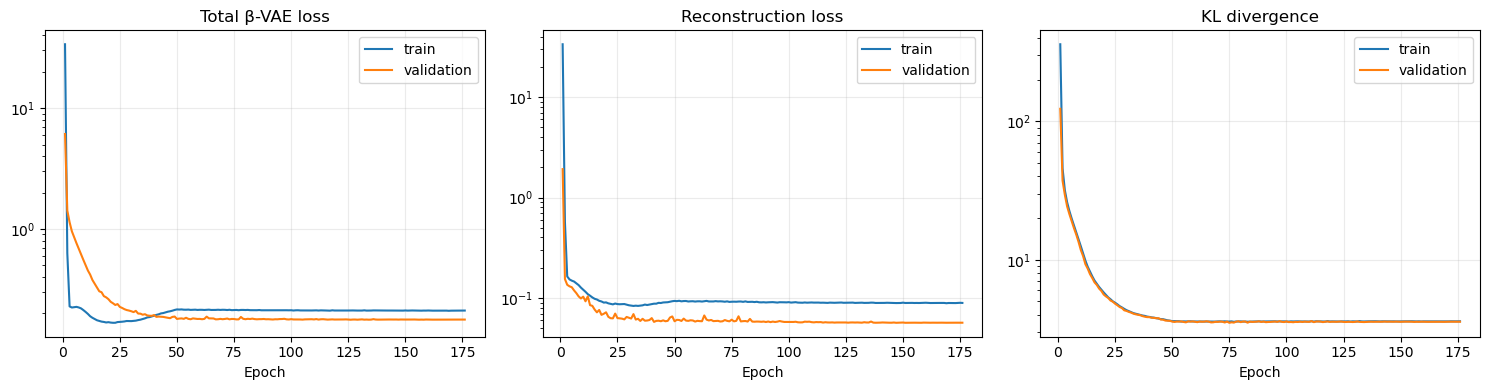

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = np.arange(1, len(history["train_total"]) + 1)
for ax, key, title in zip(
    axes, ["total", "reconstruction", "kl"],
    ["Total β-VAE loss", "Reconstruction loss", "KL divergence"],
):
    ax.plot(epochs, history[f"train_{key}"], label="train")
    ax.plot(epochs, history[f"val_{key}"], label="validation")
    ax.set(title=title, xlabel="Epoch")
    ax.set_yscale("log")
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

## Reconstruction and denoising check

The grey line is a noisy simulated acquisition, black is the deterministic VAE reconstruction obtained from the latent mean, and orange is the noise-free expected total signal. Training maps the grey input to the orange target. Metrics are reported in both transformed space and raw-count space. Peak-height and peak-position errors are calculated after subtracting the SESSA-derived background from both reconstruction and target; taking the maximum of the total spectrum is misleading for weak spectra whose rising background exceeds the actual photoelectron peak. Case-balanced summaries prevent repeated acquisitions from dominating the report.

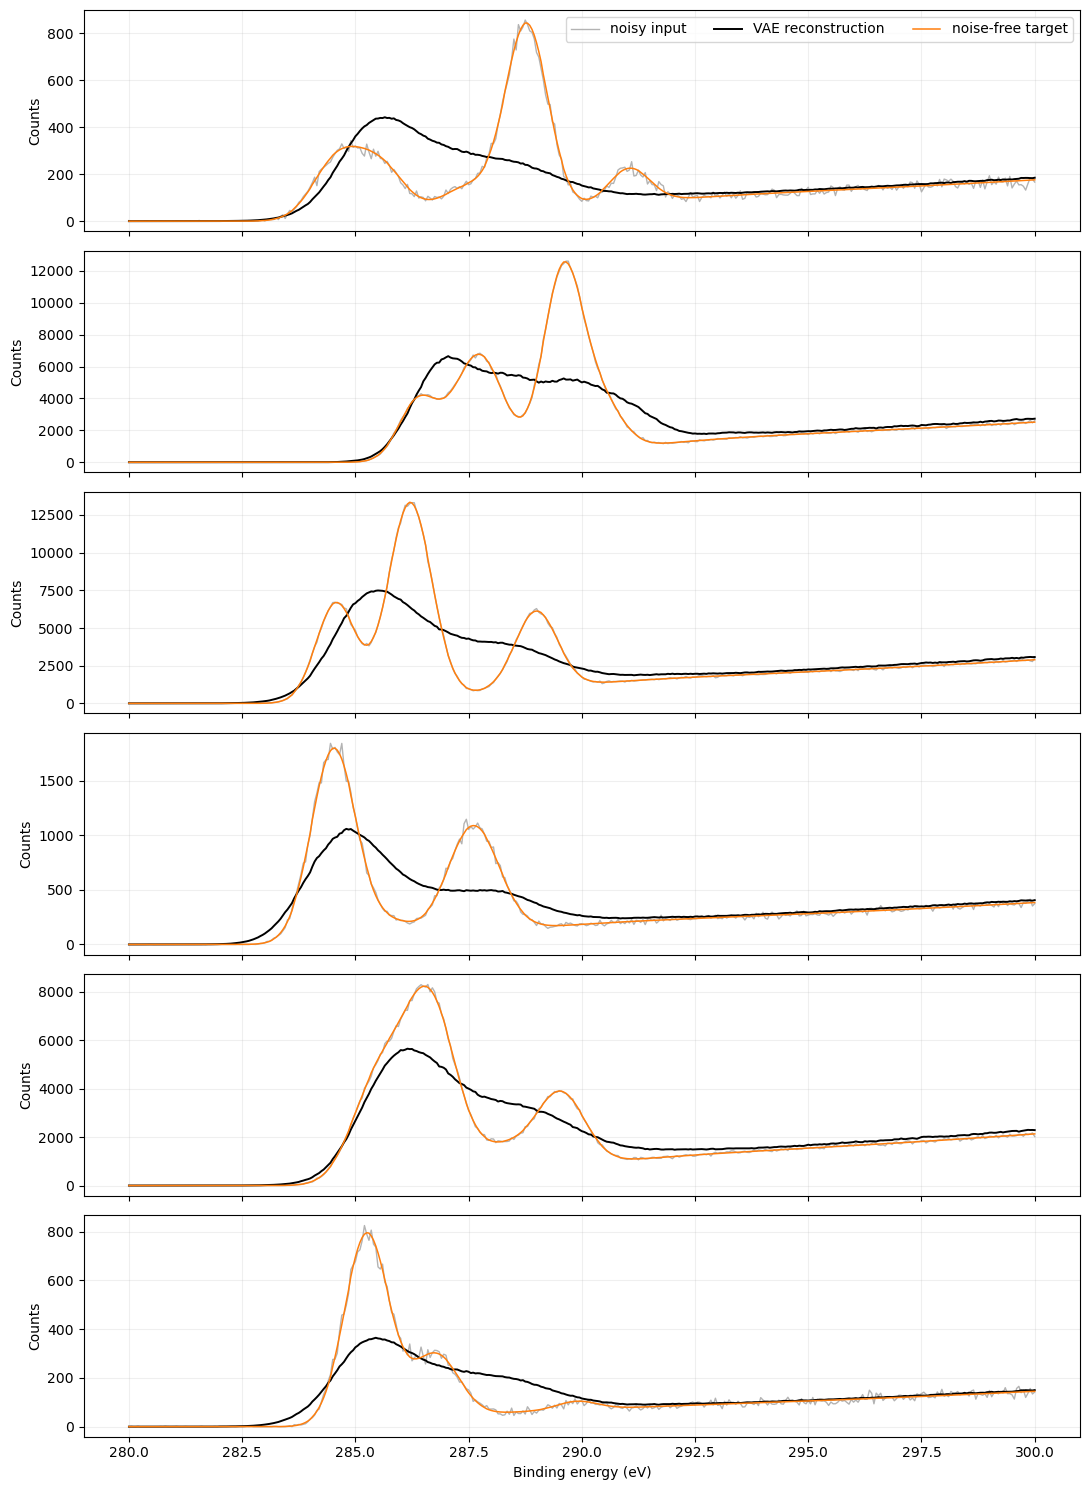

Test total=0.1789, reconstruction=0.0575, KL=3.5689
Anscombe-space MSE: 0.001522
Per-spectrum NRMSE                      p50= 0.1238  p90= 0.1694  p95= 0.1852
Integrated-area relative error          p50=  1.39%  p90=  3.82%  p95=  4.95%
Peak-height relative error              p50= 37.51%  p90= 58.88%  p95= 64.00%
Dominant-peak position error            p50= 0.5500 eV  p90= 2.6500 eV  p95= 3.3000 eV

Source-balanced medians across 1808 physical spectra:
  NRMSE=0.1236; area=1.32%; peak=36.76%; position=0.5500 eV

Metrics by target integrated-intensity quintile:
 band      n    median NRMSE    median area error    median peak error
 Q1     1808          0.1251               1.46%               39.86%
 Q2     1808          0.1238               1.52%               35.83%
 Q3     1808          0.1227               0.99%               36.54%
 Q4     1808          0.1233               1.16%               37.54%
 Q5     1808          0.1242               2.03%               37.69%


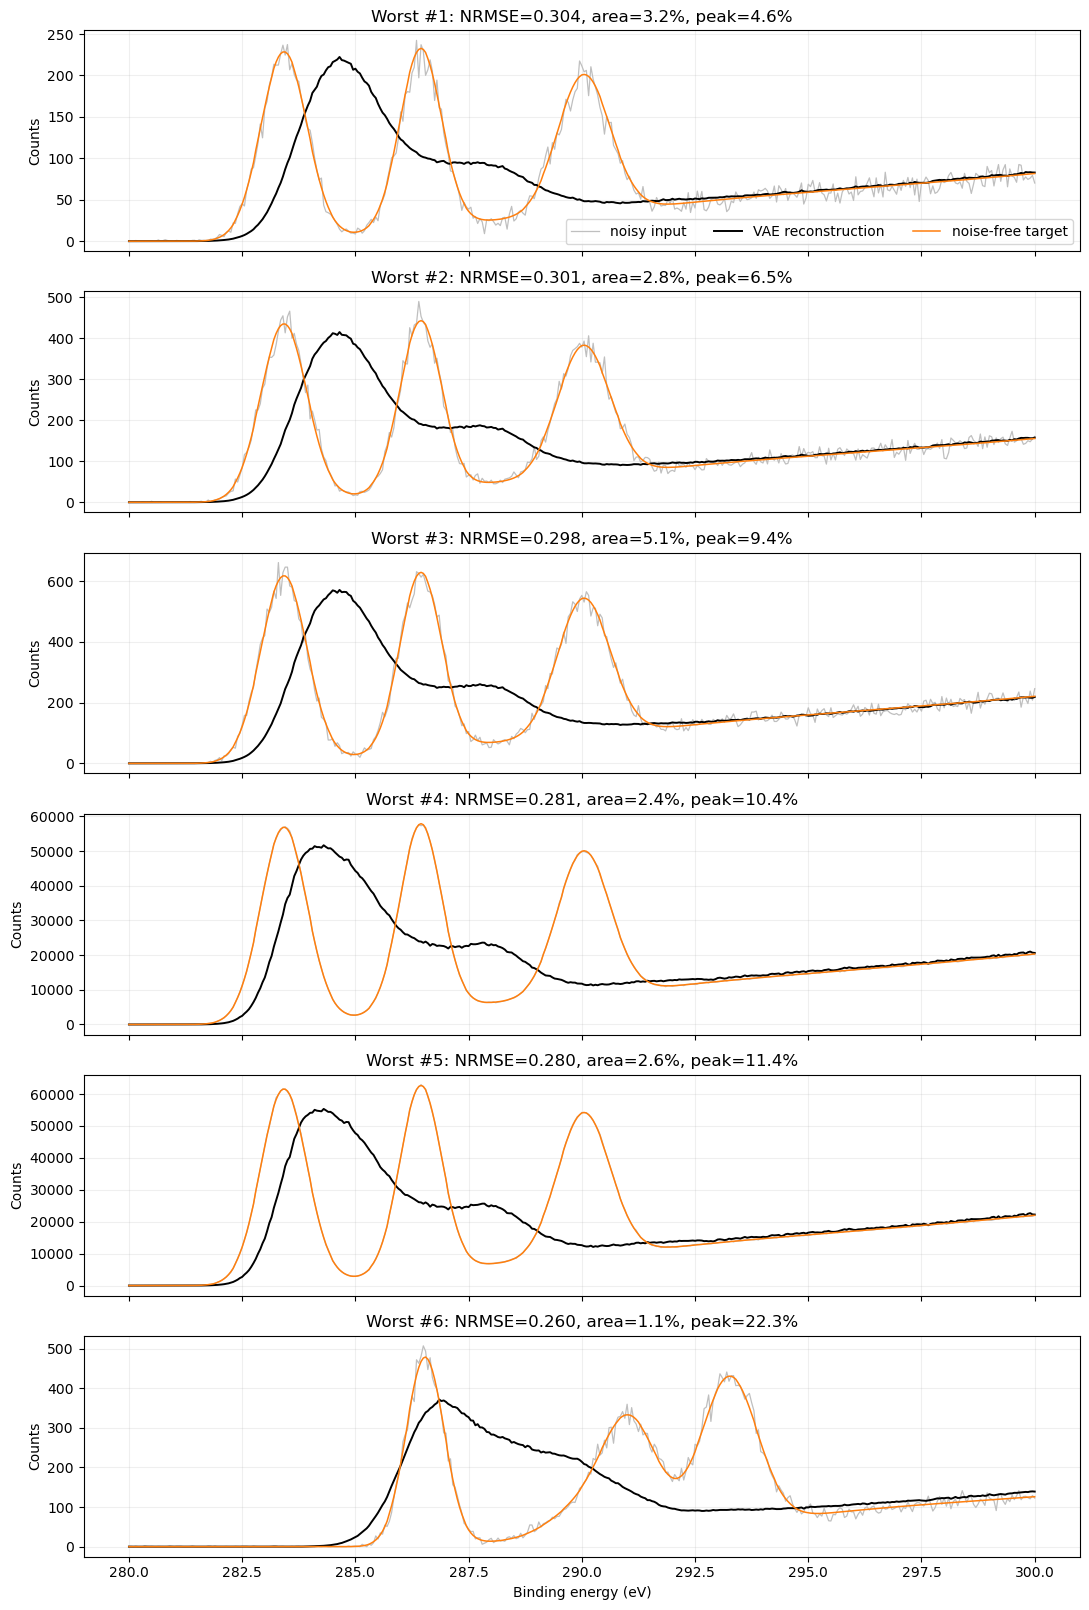

In [9]:
@torch.no_grad()
def reconstruct_from_latent_mean(model, normalized_spectra, batch_size=1024):
    model.eval()
    reconstructed = []
    for start in range(0, len(normalized_spectra), batch_size):
        x = torch.from_numpy(normalized_spectra[start:start + batch_size]).to(DEVICE)
        mu, _ = model.encode(x)
        reconstructed.append(model.decode(mu).cpu().numpy())
    return np.concatenate(reconstructed)

test_reconstruction = reconstruct_from_latent_mean(model, x_all[test_idx])
raw_test_reconstruction = denormalize_counts(test_reconstruction)
raw_test_target = dataset["expected_total"][test_idx]
raw_test_background = dataset["background"][test_idx]
axis = dataset["axis"]

plot_rng = np.random.default_rng(SEED + 1)
example_positions = plot_rng.choice(len(test_idx), size=min(6, len(test_idx)), replace=False)
example_idx = test_idx[example_positions]
fig, axes = plt.subplots(len(example_idx), 1, figsize=(11, 2.5 * len(example_idx)), sharex=True)
axes = np.atleast_1d(axes)
for ax, sample_index, position in zip(axes, example_idx, example_positions):
    ax.plot(axis, dataset["noisy"][sample_index], color="0.70", lw=1.0, label="noisy input")
    ax.plot(axis, raw_test_reconstruction[position], color="black", lw=1.4, label="VAE reconstruction")
    ax.plot(axis, raw_test_target[position], color="tab:orange", lw=1.1, label="noise-free target")
    ax.set_ylabel("Counts")
    ax.grid(alpha=0.2)
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Binding energy (eV)")
plt.tight_layout()
plt.show()

test_values = evaluate(model, test_loader)
transformed_mse = np.mean((test_reconstruction - target_all[test_idx]) ** 2)
raw_rmse = np.sqrt(np.mean((raw_test_reconstruction - raw_test_target) ** 2, axis=1))
raw_range = np.maximum(np.ptp(raw_test_target, axis=1), 1.0)
nrmse = raw_rmse / raw_range
target_area = np.maximum(raw_test_target.sum(axis=1), 1.0)
area_relative_error = np.abs(raw_test_reconstruction.sum(axis=1) - target_area) / target_area
raw_test_signal = np.maximum(raw_test_target - raw_test_background, 0.0)
raw_predicted_signal = np.maximum(raw_test_reconstruction - raw_test_background, 0.0)
target_peak = np.maximum(raw_test_signal.max(axis=1), 1.0)
peak_relative_error = np.abs(raw_predicted_signal.max(axis=1) - target_peak) / target_peak
predicted_peak_position = axis[np.argmax(raw_predicted_signal, axis=1)]
target_peak_position = axis[np.argmax(raw_test_signal, axis=1)]
peak_position_error = np.abs(predicted_peak_position - target_peak_position)

def print_quantiles(name, values, unit="", percentage=False):
    q50, q90, q95 = np.quantile(values, [0.50, 0.90, 0.95])
    if percentage:
        print(f"{name:<39} p50={q50:7.2%}  p90={q90:7.2%}  p95={q95:7.2%}")
    else:
        print(f"{name:<39} p50={q50:7.4f}{unit}  p90={q90:7.4f}{unit}  p95={q95:7.4f}{unit}")

print(f"Test total={test_values[0]:.4f}, reconstruction={test_values[1]:.4f}, KL={test_values[2]:.4f}")
print(f"Anscombe-space MSE: {transformed_mse:.6f}")
print_quantiles("Per-spectrum NRMSE", nrmse)
print_quantiles("Integrated-area relative error", area_relative_error, percentage=True)
print_quantiles("Peak-height relative error", peak_relative_error, percentage=True)
print_quantiles("Dominant-peak position error", peak_position_error, unit=" eV")

test_sources = dataset["source"][test_idx]
source_metric_rows = []
for source in np.unique(test_sources):
    mask = test_sources == source
    source_metric_rows.append([
        np.median(nrmse[mask]), np.median(area_relative_error[mask]),
        np.median(peak_relative_error[mask]), np.median(peak_position_error[mask]),
    ])
source_metric_rows = np.asarray(source_metric_rows)
print(f"\nSource-balanced medians across {len(source_metric_rows)} physical spectra:")
print(f"  NRMSE={np.median(source_metric_rows[:, 0]):.4f}; area={np.median(source_metric_rows[:, 1]):.2%}; "
      f"peak={np.median(source_metric_rows[:, 2]):.2%}; position={np.median(source_metric_rows[:, 3]):.4f} eV")

# Check whether accuracy deteriorates for weak or strong spectra.
test_intensity = raw_test_target.sum(axis=1)
quantile_edges = np.unique(np.quantile(test_intensity, np.linspace(0.0, 1.0, 6)))
print("\nMetrics by target integrated-intensity quintile:")
print(" band      n    median NRMSE    median area error    median peak error")
for band in range(len(quantile_edges) - 1):
    lower, upper = quantile_edges[band], quantile_edges[band + 1]
    mask = (test_intensity >= lower) & ((test_intensity < upper) if band < len(quantile_edges) - 2 else (test_intensity <= upper))
    if mask.any():
        print(f" Q{band + 1:<2} {mask.sum():7d} {np.median(nrmse[mask]):15.4f} "
              f"{np.median(area_relative_error[mask]):19.2%} {np.median(peak_relative_error[mask]):20.2%}")

# Inspect the tail, not only random examples or median scores.
worst_positions = np.argsort(nrmse)[-min(6, len(nrmse)):][::-1]
fig, axes = plt.subplots(len(worst_positions), 1, figsize=(11, 2.7 * len(worst_positions)), sharex=True)
axes = np.atleast_1d(axes)
for rank, (ax, position) in enumerate(zip(axes, worst_positions), start=1):
    sample_index = test_idx[position]
    ax.plot(axis, dataset["noisy"][sample_index], color="0.75", lw=0.9, label="noisy input")
    ax.plot(axis, raw_test_reconstruction[position], color="black", lw=1.4, label="VAE reconstruction")
    ax.plot(axis, raw_test_target[position], color="tab:orange", lw=1.1, label="noise-free target")
    ax.set_ylabel("Counts")
    ax.set_title(f"Worst #{rank}: NRMSE={nrmse[position]:.3f}, area={area_relative_error[position]:.1%}, peak={peak_relative_error[position]:.1%}")
    ax.grid(alpha=0.2)
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Binding energy (eV)")
plt.tight_layout()
plt.show()

## Compare the latent space with known physical parameters

The atmospheric dataset provides ground-truth peak, composition, aging, density, band-gap, and charging labels, while intensity and background summaries can be calculated directly. Repeated acquisitions are averaged by physical case before correlations are calculated. Constant labels are reported and excluded instead of generating invalid correlations. Highly collinear labels are also reported because a VAE cannot uniquely disentangle variables that never vary independently.

Physical spectra used for correlation: 1808
Excluded constant/non-finite labels: ['photon energy']
Collinear labels: CC_CH center and C_O center (r=+0.986)
Collinear labels: CC_CH center and C_eq_O center (r=+0.984)
Collinear labels: CC_CH center and O_C_eq_O center (r=+0.984)
Collinear labels: CC_CH center and charge shift (r=+0.996)
Collinear labels: C_O center and charge shift (r=+0.990)
Collinear labels: C_eq_O center and charge shift (r=+0.988)
Collinear labels: O_C_eq_O center and charge shift (r=+0.988)
Collinear labels: log total area and log background area (r=+0.994)


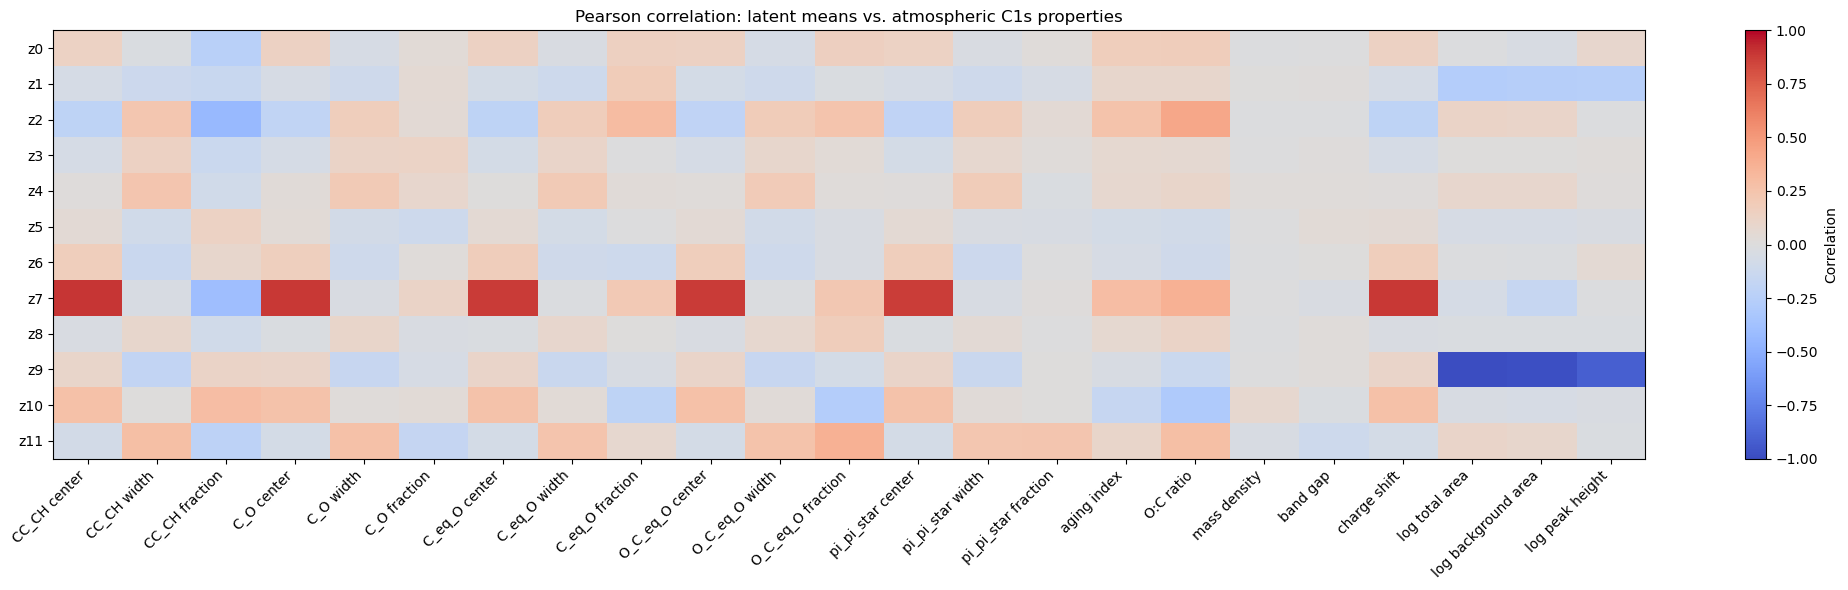

        CC_CH center: z7 (r=+0.893)
         CC_CH width: z11 (r=+0.286)
      CC_CH fraction: z2 (r=-0.432)
          C_O center: z7 (r=+0.887)
           C_O width: z11 (r=+0.270)
        C_O fraction: z11 (r=-0.171)
       C_eq_O center: z7 (r=+0.880)
        C_eq_O width: z11 (r=+0.250)
     C_eq_O fraction: z2 (r=+0.304)
     O_C_eq_O center: z7 (r=+0.877)
      O_C_eq_O width: z11 (r=+0.254)
   O_C_eq_O fraction: z11 (r=+0.368)
   pi_pi_star center: z7 (r=+0.869)
    pi_pi_star width: z11 (r=+0.234)
 pi_pi_star fraction: z11 (r=+0.237)
         aging index: z7 (r=+0.290)
           O:C ratio: z2 (r=+0.424)
        mass density: z10 (r=+0.072)
            band gap: z11 (r=-0.111)
        charge shift: z7 (r=+0.890)
      log total area: z9 (r=-0.984)
 log background area: z9 (r=-0.978)
     log peak height: z9 (r=-0.906)


In [10]:
@torch.no_grad()
def encode_distributions(model, normalized_spectra, batch_size=1024):
    model.eval()
    means, log_variances = [], []
    for start in range(0, len(normalized_spectra), batch_size):
        x = torch.from_numpy(normalized_spectra[start:start + batch_size]).to(DEVICE)
        mu, logvar = model.encode(x)
        means.append(mu.cpu().numpy())
        log_variances.append(logvar.cpu().numpy())
    return np.concatenate(means), np.concatenate(log_variances)

def encode_means(model, normalized_spectra, batch_size=1024):
    means, _ = encode_distributions(model, normalized_spectra, batch_size)
    return means

z_test = encode_means(model, x_all[test_idx])
label_columns = {}
for i, component_name in enumerate(dataset["component_names"]):
    label_columns[f"{component_name} center"] = dataset["peak_center"][test_idx, i]
    label_columns[f"{component_name} width"] = dataset["peak_width"][test_idx, i]
    label_columns[f"{component_name} fraction"] = dataset["peak_fraction"][test_idx, i]
for key, label in (("aging_index", "aging index"),
                   ("oxygen_to_carbon_ratio", "O:C ratio"),
                   ("mass_density_g_cm3", "mass density"),
                   ("band_gap_eV", "band gap"),
                   ("charge_shift_eV", "charge shift")):
    label_columns[label] = dataset[key][test_idx]
label_columns["photon energy"] = dataset["photon_energy"][test_idx]
label_columns["log total area"] = np.log1p(dataset["expected_total"][test_idx].sum(axis=1))
label_columns["log background area"] = np.log1p(dataset["background"][test_idx].sum(axis=1))
label_columns["log peak height"] = np.log1p(dataset["expected_total"][test_idx].max(axis=1))

physical_names_all = list(label_columns)
physical_all = np.column_stack([label_columns[name] for name in physical_names_all])
test_sources = dataset["source"][test_idx]
unique_test_sources = np.unique(test_sources)
z_by_source = []
physical_by_source = []
for source in unique_test_sources:
    mask = test_sources == source
    z_by_source.append(z_test[mask].mean(axis=0))
    physical_by_source.append(physical_all[mask].mean(axis=0))
z_by_source = np.asarray(z_by_source)
physical_by_source = np.asarray(physical_by_source)

varying = np.isfinite(physical_by_source).all(axis=0) & (np.ptp(physical_by_source, axis=0) > 1e-6)
excluded_names = [name for name, keep in zip(physical_names_all, varying) if not keep]
physical_names = [name for name, keep in zip(physical_names_all, varying) if keep]
physical = physical_by_source[:, varying]
print(f"Physical spectra used for correlation: {len(unique_test_sources)}")
print(f"Excluded constant/non-finite labels: {excluded_names or 'none'}")

correlation = np.empty((z_by_source.shape[1], physical.shape[1]), dtype=np.float64)
for i in range(z_by_source.shape[1]):
    for j in range(physical.shape[1]):
        correlation[i, j] = np.corrcoef(z_by_source[:, i], physical[:, j])[0, 1]

label_correlation = np.corrcoef(physical, rowvar=False)
for i in range(len(physical_names)):
    for j in range(i + 1, len(physical_names)):
        if abs(label_correlation[i, j]) >= 0.98:
            print(f"Collinear labels: {physical_names[i]} and {physical_names[j]} (r={label_correlation[i, j]:+.3f})")

fig, ax = plt.subplots(figsize=(max(10, 0.9 * len(physical_names)), 6))
image = ax.imshow(correlation, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
ax.set_xticks(np.arange(len(physical_names)), physical_names, rotation=45, ha="right")
ax.set_yticks(np.arange(12), [f"z{i}" for i in range(12)])
ax.set_title("Pearson correlation: latent means vs. atmospheric C1s properties")
fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

for j, name in enumerate(physical_names):
    best = int(np.argmax(np.abs(correlation[:, j])))
    print(f"{name:>20}: z{best} (r={correlation[best, j]:+.3f})")

## Generate spectra from this dataset's encoded latent space

The saved run uses only two appreciably varying latent means. To generate spectra without a standard-normal latent draw, the cell below encodes one acquisition per training case and interpolates between nearby encoder means. Each new latent vector lies between two observed training cases. These outputs are decoded interpolations; their sharp-peak accuracy is limited by the trained decoder, so inspect them alongside the test reconstruction metrics above.


In [ ]:
N_GENERATED = 12
train_case_representatives = case_representative[case_split == "train"]
train_latent_means = encode_means(model, x_all[train_case_representatives])
mean_std = train_latent_means.std(axis=0)
informative_dimensions = np.flatnonzero(mean_std > 0.05)
print("Std of encoder means:", np.round(mean_std, 3))
print("Informative latent dimensions:", informative_dimensions.tolist())
if informative_dimensions.size == 0:
    raise RuntimeError("All encoder means are nearly constant; latent interpolation is not meaningful.")

# Select nearby cases in the active latent coordinates, then interpolate their means.
# No standard-normal latent draw or encoder variance is used for generation.
generation_rng = np.random.default_rng(SEED + 2)
scaled_means = train_latent_means[:, informative_dimensions] / mean_std[informative_dimensions]
anchor_rows = generation_rng.choice(len(train_latent_means), size=N_GENERATED, replace=False)
interpolated_latents = []
for anchor in anchor_rows:
    candidate_rows = generation_rng.choice(len(train_latent_means), size=min(512, len(train_latent_means)), replace=False)
    candidate_rows = candidate_rows[candidate_rows != anchor]
    distances = np.sum((scaled_means[candidate_rows] - scaled_means[anchor]) ** 2, axis=1)
    nearby_rows = candidate_rows[np.argsort(distances)[:20]]
    neighbor = generation_rng.choice(nearby_rows)
    weight = generation_rng.uniform(0.25, 0.75)
    interpolated_latents.append((1.0 - weight) * train_latent_means[anchor] + weight * train_latent_means[neighbor])

model.eval()
with torch.no_grad():
    latent_tensor = torch.from_numpy(np.asarray(interpolated_latents, dtype=np.float32)).to(DEVICE)
    generated_normalized = model.decode(latent_tensor).cpu().numpy()
generated_counts = denormalize_counts(generated_normalized)

fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=True)
for ax, spectrum in zip(axes.flat, generated_counts):
    ax.plot(axis, spectrum, color="tab:blue", lw=1.2)
    ax.grid(alpha=0.2)
for ax in axes[-1]:
    ax.set_xlabel("Binding energy (eV)")
for ax in axes[:, 0]:
    ax.set_ylabel("Counts")
fig.suptitle("β-VAE decoded interpolations between training cases", y=1.01)
plt.tight_layout()
plt.show()


## Interpretation

The saved run does not preserve sharp C1s components: its median test peak-height error is 37.51%, and the six worst test reconstructions merge distinct peaks into broad humps. The reconstruction objective gives a strong incentive to match integrated area, while the derivative terms are too weak to preserve narrow peaks. KL regularization leaves only two active latent means, mainly aligned with charging/peak position and total intensity. The other ten means vary so little that they carry negligible case-specific information.

The generation cell above interpolates encoded training cases. This removes latent sampling from the standard normal, but it cannot repair missing peak detail: that requires a better trained decoder and a loss that resolves individual peaks. Compare the separate vanilla VAE notebook on the same dataset and report peak-height and position errors, not just total loss or area error.
